In [1]:
import torch
from evaluation_metrics import curve_posterior_slerp_deviation, curve_false_pos, curve_true_pos
from utils import NestedDiagonalGMM
from geometry_tools import lerp
from pretrained_models import NestedVAE
from torch.nn.functional import cross_entropy, mse_loss
from typing import NamedTuple
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
import torchvision.transforms.functional as F
import numpy as np
from tqdm import tqdm
from torchmetrics.image import LearnedPerceptualImagePatchSimilarity as LPIPS, StructuralSimilarityIndexMeasure as SSIM, DeepImageStructureAndTextureSimilarity as DISTS

def show_img(img, figsize=None, ax=None):
    if not ax:
        fig = plt.figure(figsize=figsize)
        ax = fig.add_subplot()
    img = img.detach()
    img = F.to_pil_image(img)
    ax.imshow(np.asarray(img), cmap='gray')
    ax.set(xticklabels=[], yticklabels=[], xticks=[], yticks=[])

/usr/people/robertwiebe/testvenv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
vae = NestedVAE()

/usr/people/robertwiebe/testvenv/lib/python3.11/site-packages/huggingface_hub/utils/_validators.py:206: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
/net/st1/export/clusterhome/robertwiebe/ml_geometry_project/pretrained_models.py:280: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torc

In [3]:
from matplotlib.ticker import MultipleLocator
def show_latent_curve(curve: torch.Tensor, title=None, ax=None):
    if not ax:
        fig = plt.figure(figsize=(12, 1.25))
        ax = fig.add_subplot()
    with torch.no_grad():
        img = make_grid(vae.decode(curve), nrow=curve.shape[0])
    img = F.to_pil_image(img)
    ax.imshow(np.asarray(img), cmap='gray', extent=(0, 1, 0, 1/len(curve)))
    ax.yaxis.set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)
    ax.spines["bottom"].set_visible(True)
    ax.xaxis.set_major_locator(MultipleLocator(0.1))
    # ax.set_xlim(0, 1)
    if title: ax.set_title(title)

attribute_names = ["5_o_Clock_Shadow", "Arched_Eyebrows", "Attractive", "Bags_Under_Eyes", "Bald", "Bangs", "Big_Lips", "Big_Nose", "Black_Hair", "Blond_Hair", "Blurry", "Brown_Hair", "Bushy_Eyebrows", "Chubby", "Double_Chin", "Eyeglasses", "Goatee", "Gray_Hair", "Heavy_Makeup", "High_Cheekbones", "Male", "Mouth_Slightly_Open", "Mustache", "Narrow_Eyes", "No_Beard", "Oval_Face", "Pale_Skin", "Pointy_Nose", "Receding_Hairline", "Rosy_Cheeks", "Sideburns", "Smiling", "Straight_Hair", "Wavy_Hair", "Wearing_Earrings", "Wearing_Hat", "Wearing_Lipstick", "Wearing_Necklace", "Wearing_Necktie", "Young"]

def show_posterior(curve: torch.Tensor, log_posterior, title=None, ax=None, top_n_labels: int | None = None):
    with torch.no_grad():
        posterior = torch.exp(log_posterior(curve.cuda()).cpu())
    if not ax:
        fig = plt.figure()
        ax = fig.add_subplot()
    if top_n_labels:
        prominence = posterior.sum(dim=0)
        order = prominence.sort(descending=True).indices
        top, others = order[:top_n_labels], order[top_n_labels:]
        ax.plot(
            posterior[:, top],
            label=[attribute_names[i] for i in top]
        )
        ax.plot(posterior[:, others], c='gray')
        ax.legend()
    else:
        ax.plot(posterior)
    if title: ax.set_title(title)

In [4]:
nested_gmm_params = torch.load('trained_checkpoints/celeba_nested_nested_gmm_4.pt')
nested_gmm = NestedDiagonalGMM(
    means=nested_gmm_params['means'],
    variances=nested_gmm_params['variances'],
    subweights=nested_gmm_params['subweights'],
    supweights=nested_gmm_params['supweights'],
)

/tmp/user/5678/ipykernel_3740595/2406645237.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  nested_gmm_params = torch.load('trained_checkpoints/celeba_nested_nested_gmm_

In [5]:
class InterpolationGroup(NamedTuple):
    linline: torch.Tensor
    dec_geodesic: torch.Tensor
    ebm_geodesic: torch.Tensor
    geodesic: torch.Tensor
    labels: torch.Tensor

In [6]:
interpolations = torch.load('pickled_objects/interpolations.pt')

/tmp/user/5678/ipykernel_3740595/2199534052.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  interpolations = torch.load('pickled_objects/interpolations.pt')


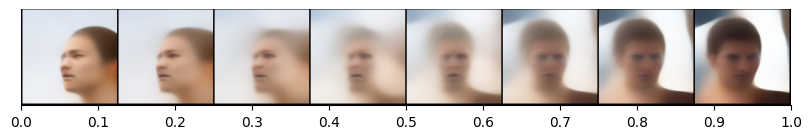

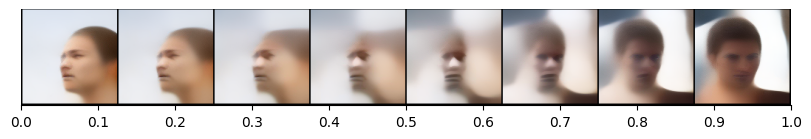

In [31]:
linline, dec_geodesic, ebm_geodesic, geodesic, labels = interpolations[28]
show_latent_curve(linline)
show_latent_curve(geodesic)

In [52]:
lpips = LPIPS(net_type='vgg', reduction='none', normalize=True)

/usr/people/robertwiebe/testvenv/lib/python3.11/site-packages/torchmetrics/functional/image/lpips.py:332: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.load_state_dict(

In [8]:
lpips = LPIPS(net_type='alex', reduction='none', normalize=True)

/usr/people/robertwiebe/testvenv/lib/python3.11/site-packages/torchmetrics/functional/image/lpips.py:332: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.load_state_dict(

In [24]:
ssim = SSIM(reduction='none')

In [31]:
with torch.inference_mode():
    im1 = vae.decode(linline[0]).clamp(max=1.0).unsqueeze(0)
    im2 = vae.decode(linline[3]).clamp(max=1.0).unsqueeze(0)
    print(lpips(im1, im2))

tensor(0.5126)


In [32]:
with torch.inference_mode():
    im1 = vae.decode(geodesic[0]).clamp(max=1.0).unsqueeze(0)
    im2 = vae.decode(geodesic[3]).clamp(max=1.0).unsqueeze(0)
    print(lpips(im1, im2))

tensor(0.4692)


In [18]:
with torch.inference_mode():
    decoded = vae.decode(linline).clamp(0.0, 1.0)
    print(lpips(decoded[[0]], decoded).sum())

tensor(1.5126)


In [19]:
with torch.inference_mode():
    decoded = vae.decode(geodesic).clamp(0.0, 1.0)
    print(lpips(decoded[[0]], decoded).sum())

tensor(1.5913)


In [20]:
with torch.inference_mode():
    decoded = vae.decode(linline).clamp(0.0, 1.0)
    print(lpips(decoded[[-1]], decoded).sum())

tensor(1.7777)


In [21]:
with torch.inference_mode():
    decoded = vae.decode(geodesic).clamp(0.0, 1.0)
    print(lpips(decoded[[-1]], decoded).sum())

tensor(2.2774)


In [29]:
with torch.inference_mode():
    decoded = vae.decode(linline).clamp(0.0, 1.0)
    print(ssim(decoded[[-1]].expand_as(decoded), decoded))

tensor([0.4552, 0.5031, 0.5561, 0.6218, 0.7058, 0.8096, 0.9268, 1.0000])


In [28]:
with torch.inference_mode():
    decoded = vae.decode(geodesic).clamp(0.0, 1.0)
    print(ssim(decoded[[-1]].expand_as(decoded), decoded))

tensor([0.4552, 0.5058, 0.5363, 0.5817, 0.6368, 0.6967, 0.7955, 1.0000])


In [ ]:
lpips()